In [1]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [2]:
# building a perfect circuit
qc = QuantumCircuit(2,2)
qc.h(0)
qc.cx(0,1)
qc.measure([0,1],[0,1])

In [3]:
# define the wireless static (15% noise)
noise_prob = 0.15
error_1 = depolarizing_error(noise_prob,1) # noise will hit 1 qubit
error_2 = depolarizing_error(noise_prob,2) # noise will hit 2 qubits

In [4]:
# building the environment
noise_model = NoiseModel()
# telling the enivironment to attack the H gate and the CX gate
noise_model.add_all_qubit_quantum_error(error_1,['h'])
noise_model.add_all_qubit_quantum_error(error_2,['cx'])

In [5]:
# booting up the simulator with noise model
simulator = AerSimulator(noise_model=noise_model)
compiled_circuit = transpile(qc,simulator)

In [6]:
# running the simulator for 1024 times through the noisy air
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()

Corrupted Quantum key result:  {'11': 467, '00': 480, '10': 41, '01': 36}


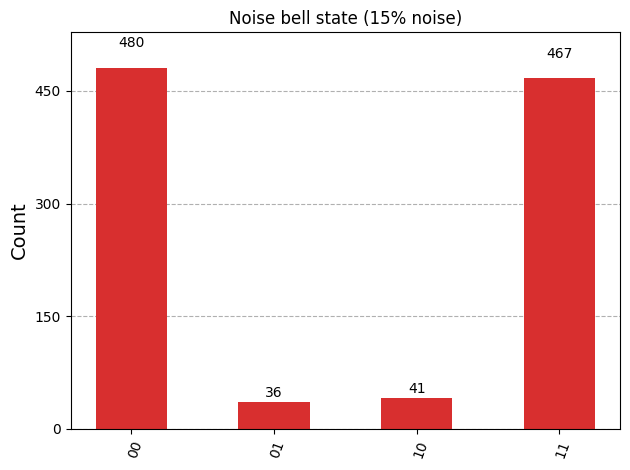

In [7]:
# output data and graph
print("Corrupted Quantum key result: ",counts)
fig = plot_histogram(counts, title="Noise bell state (15% noise)", color='#d82f2f')